In [1]:
import numpy as np,pandas as pd,matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"C:\Users\Hani\Downloads\HR-Employee-Attrition (1).csv")

In [3]:
df.shape

(1470, 35)

In [4]:
df.Attrition.value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [5]:
df.select_dtypes('object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Y,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Y,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
...,...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,Y,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Y,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,Y,No


In [6]:
df.drop('Over18',axis=1,inplace=True)

In [7]:
df.select_dtypes('object').iloc[:,1:].shape

(1470, 7)

In [8]:
from sklearn.preprocessing import OneHotEncoder

In [9]:
ohe = OneHotEncoder(sparse_output=False,drop='first')
ohe.fit_transform(df.select_dtypes('object').iloc[:,1:]).shape

(1470, 21)

In [10]:
df.drop(df.select_dtypes('object').columns,axis=1).shape

(1470, 26)

In [11]:
x=[10,20,30]

In [12]:
x

[10, 20, 30]

In [13]:
y=x.copy()

In [14]:
y[0]=100

In [15]:
y

[100, 20, 30]

In [16]:
x

[10, 20, 30]

In [17]:
res = lambda x: 'Hi' if x != 'Introvert' else 'Goodbye'

In [18]:
person1= 'Introvert' 

In [19]:
res(person1)

'Goodbye'

In [20]:
df.Attrition= df.Attrition.apply(lambda x: 1 if x=='Yes' else 0)

In [21]:
 df.Attrition

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

In [22]:
num_df=df.drop(df.select_dtypes('object').columns,axis=1)
num_df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,1102,1,2,1,1,2,94,3,...,1,80,0,8,0,1,6,4,0,5
1,49,0,279,8,1,1,2,3,61,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,1373,2,2,1,4,4,92,2,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1392,3,4,1,5,4,56,3,...,3,80,0,8,3,3,8,7,3,0
4,27,0,591,2,1,1,7,1,40,3,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,1,2061,3,41,4,...,3,80,1,17,3,3,5,2,0,3
1466,39,0,613,6,1,1,2062,4,42,2,...,1,80,1,9,5,3,7,7,1,7
1467,27,0,155,4,3,1,2064,2,87,4,...,2,80,1,6,0,3,6,2,0,3
1468,49,0,1023,2,3,1,2065,4,63,2,...,4,80,0,17,3,2,9,6,0,8


In [23]:
num_df.corr()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,-0.159205,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,...,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
Attrition,-0.159205,1.000000,-0.056652,0.077924,-0.031373,NaN,-0.010577,-0.103369,-0.006846,-0.130016,...,-0.045872,NaN,-0.137145,-0.171063,-0.059478,-0.063939,-0.134392,-0.160545,-0.033019,-0.156199
DailyRate,0.010661,-0.056652,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,...,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,0.077924,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,...,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.031373,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,...,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.010577,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,...,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197
EnvironmentSatisfaction,0.010146,-0.103369,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,...,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,-0.006846,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,...,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,-0.130016,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,...,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976


In [24]:
cors=num_df.corr()

In [25]:
cors['Attrition']

Age                        -0.159205
Attrition                   1.000000
DailyRate                  -0.056652
DistanceFromHome            0.077924
Education                  -0.031373
EmployeeCount                    NaN
EmployeeNumber             -0.010577
EnvironmentSatisfaction    -0.103369
HourlyRate                 -0.006846
JobInvolvement             -0.130016
JobLevel                   -0.169105
JobSatisfaction            -0.103481
MonthlyIncome              -0.159840
MonthlyRate                 0.015170
NumCompaniesWorked          0.043494
PercentSalaryHike          -0.013478
PerformanceRating           0.002889
RelationshipSatisfaction   -0.045872
StandardHours                    NaN
StockOptionLevel           -0.137145
TotalWorkingYears          -0.171063
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
YearsAtCompany             -0.134392
YearsInCurrentRole         -0.160545
YearsSinceLastPromotion    -0.033019
YearsWithCurrManager       -0.156199
N

In [26]:
cors = num_df.corr()['Attrition']
for i in cors.index:
  if np.sqrt(cors[i]**2) < 0.05:
    print(i, '---->', cors[i])
    num_df.drop(i, axis=1, inplace=True)

Education ----> -0.031372819640049315
EmployeeNumber ----> -0.010577242759242786
HourlyRate ----> -0.006845549572139952
MonthlyRate ----> 0.015170212530471473
NumCompaniesWorked ----> 0.04349373905781363
PercentSalaryHike ----> -0.01347820205743911
PerformanceRating ----> 0.0028887517110809
RelationshipSatisfaction ----> -0.0458722788811267
YearsSinceLastPromotion ----> -0.033018775142584306


In [27]:
num_df.shape

(1470, 18)

In [28]:
num_df.head(2)

,Age,Attrition,DailyRate,DistanceFromHome,EmployeeCount,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager
0,41,1,1102,1,1,2,3,2,4,5993,80,0,8,0,1,6,4,5
1,49,0,279,8,1,3,2,2,2,5130,80,1,10,3,3,10,7,7


In [29]:
import seaborn as sns

<Axes: >

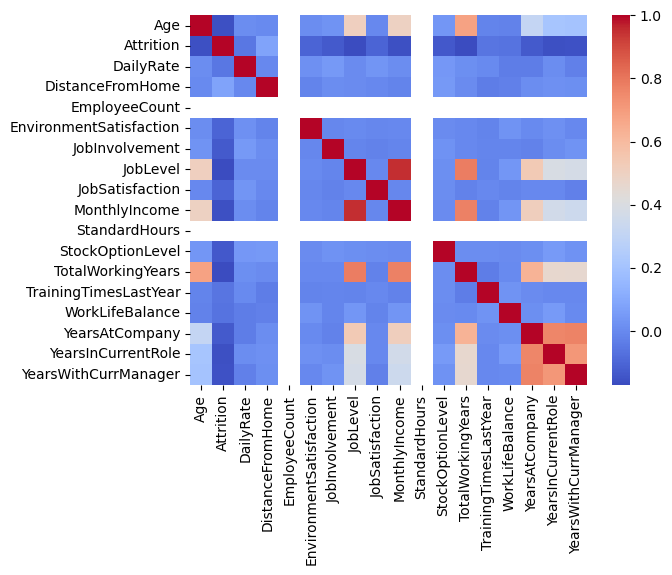

In [30]:
sns.heatmap(num_df.corr(),cmap='coolwarm')

In [31]:
cors = num_df.corr()
for i in cors.columns:
  if i !='Attrition':
    for j in cors[i].index:
      if i!=j and np.sqrt(cors[i][j]**2) > 0.95:
        print(i,j,'---->', cors[i][j])

JobLevel MonthlyIncome ----> 0.9502999134798473
MonthlyIncome JobLevel ----> 0.9502999134798473


In [32]:
len(num_df.JobLevel.unique())

5

In [33]:
len(num_df.MonthlyIncome.unique())

1349

In [34]:
num_df.drop(['MonthlyIncome'],axis=1,inplace=True)

In [35]:
num_df.shape

(1470, 17)

In [36]:
ohe

OneHotEncoder(drop='first', sparse_output=False)

In [37]:
for i in df.select_dtypes('object'):
  print(i,len(df[i].unique()))

BusinessTravel 3
Department 3
EducationField 6
Gender 2
JobRole 9
MaritalStatus 3
OverTime 2


In [38]:
categorical_df = df.select_dtypes('object').drop(columns='Attrition', errors='ignore')
ohe = OneHotEncoder(sparse_output=False, drop='first', dtype='int8')
cat_df = pd.DataFrame(
    ohe.fit_transform(categorical_df),
    columns=ohe.get_feature_names_out(categorical_df.columns),
    index=df.index,
)
cat_df

,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
1,1,0,1,0,1,0,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
2,0,1,1,0,0,0,0,1,0,1,...,1,0,0,0,0,0,0,0,1,1
3,1,0,1,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,1
4,0,1,1,0,0,0,1,0,0,1,...,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,1,0,1,0,0,0,1,0,0,1,...,1,0,0,0,0,0,0,1,0,0
1466,0,1,1,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1467,0,1,1,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,1,0,1
1468,1,0,0,1,0,0,1,0,0,1,...,0,0,0,0,0,1,0,1,0,0


In [39]:
new_df = pd.concat([num_df, cat_df], axis=1)
new_df

,Age,Attrition,DailyRate,DistanceFromHome,EmployeeCount,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,StandardHours,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,1,2,3,2,4,80,...,0,0,0,0,0,1,0,0,1,1
1,49,0,279,8,1,3,2,2,2,80,...,0,0,0,0,1,0,0,1,0,0
2,37,1,1373,2,1,4,2,1,3,80,...,1,0,0,0,0,0,0,0,1,1
3,33,0,1392,3,1,4,3,1,3,80,...,0,0,0,0,1,0,0,1,0,1
4,27,0,591,2,1,1,3,1,2,80,...,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,1,3,4,2,4,80,...,1,0,0,0,0,0,0,1,0,0
1466,39,0,613,6,1,4,2,3,1,80,...,0,0,0,0,0,0,0,1,0,0
1467,27,0,155,4,1,2,4,2,2,80,...,0,0,1,0,0,0,0,1,0,1
1468,49,0,1023,2,1,4,2,2,2,80,...,0,0,0,0,0,1,0,1,0,0


In [40]:
X = new_df.drop('Attrition', axis=1)
y = new_df.Attrition

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    random_state=16,
                                                    test_size=0.2)


In [42]:
from sklearn.tree import DecisionTreeClassifier

In [43]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [44]:
y_pred = model.predict(X_test)

In [45]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.88      0.88       247
           1       0.40      0.40      0.40        47

    accuracy                           0.81       294
   macro avg       0.64      0.64      0.64       294
weighted avg       0.81      0.81      0.81       294



In [46]:
pd.crosstab(y_test, y_pred)

col_0,0,1
Attrition,,
0,218,29
1,28,19


In [47]:
param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],  # Splitting criteria
    "max_depth": [None, 3, 5, 10, 20],             # Tree depth
    "min_samples_split": [2, 5, 10],               # Min samples to split a node
    "min_samples_leaf": [2,3,4,5,6,7,8],                 # Min samples at a leaf node
    "max_features": [None, "sqrt", "log2"],        # Features considered at each split
    "splitter": ["best", "random"]                 # Split strategy
}

In [48]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=2, verbose=3,scoring ='f1')
grid

GridSearchCV(cv=2, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [None, 3, 5, 10, 20],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [2, 3, 4, 5, 6, 7, 8],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']},
             scoring='f1', verbose=3)

In [49]:
grid.fit(X_train, y_train)

Fitting 2 folds for each of 1890 candidates, totalling 3780 fits
[CV 1/2] END criterion=gini, max_depth=None, max_features=None, min_samples_leaf=2, min_samples_split=2, splitter=best;, score=0.361 total time=   0.0s
[CV 2/2] END criterion=gini, max_depth=None, max_features=None, min_samples_leaf=2, min_samples_split=2, splitter=best;, score=0.272 total time=   0.0s
[CV 1/2] END criterion=gini, max_depth=None, max_features=None, min_samples_leaf=2, min_samples_split=2, splitter=random;, score=0.349 total time=   0.0s
[CV 2/2] END criterion=gini, max_depth=None, max_features=None, min_samples_leaf=2, min_samples_split=2, splitter=random;, score=0.212 total time=   0.0s
[CV 1/2] END criterion=gini, max_depth=None, max_features=None, min_samples_leaf=2, min_samples_split=5, splitter=best;, score=0.311 total time=   0.0s
[CV 2/2] END criterion=gini, max_depth=None, max_features=None, min_samples_leaf=2, min_samples_split=5, splitter=best;, score=0.293 total time=   0.0s
[CV 1/2] END criter

[CV 1/2] END criterion=gini, max_depth=None, max_features=None, min_samples_leaf=7, min_samples_split=5, splitter=best;, score=0.371 total time=   0.0s
[CV 2/2] END criterion=gini, max_depth=None, max_features=None, min_samples_leaf=7, min_samples_split=5, splitter=best;, score=0.355 total time=   0.0s
[CV 1/2] END criterion=gini, max_depth=None, max_features=None, min_samples_leaf=7, min_samples_split=5, splitter=random;, score=0.346 total time=   0.0s
[CV 2/2] END criterion=gini, max_depth=None, max_features=None, min_samples_leaf=7, min_samples_split=5, splitter=random;, score=0.349 total time=   0.0s
[CV 1/2] END criterion=gini, max_depth=None, max_features=None, min_samples_leaf=7, min_samples_split=10, splitter=best;, score=0.371 total time=   0.0s
[CV 2/2] END criterion=gini, max_depth=None, max_features=None, min_samples_leaf=7, min_samples_split=10, splitter=best;, score=0.317 total time=   0.0s
[CV 1/2] END criterion=gini, max_depth=None, max_features=None, min_samples_leaf=7

[CV 1/2] END criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=6, min_samples_split=2, splitter=best;, score=0.344 total time=   0.0s
[CV 2/2] END criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=6, min_samples_split=2, splitter=best;, score=0.325 total time=   0.0s
[CV 1/2] END criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=6, min_samples_split=2, splitter=random;, score=0.149 total time=   0.0s
[CV 2/2] END criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=6, min_samples_split=2, splitter=random;, score=0.265 total time=   0.0s
[CV 1/2] END criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=6, min_samples_split=5, splitter=best;, score=0.230 total time=   0.0s
[CV 2/2] END criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=6, min_samples_split=5, splitter=best;, score=0.205 total time=   0.0s
[CV 1/2] END criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=6, 

[CV 2/2] END criterion=gini, max_depth=None, max_features=log2, min_samples_leaf=3, min_samples_split=10, splitter=best;, score=0.273 total time=   0.0s
[CV 1/2] END criterion=gini, max_depth=None, max_features=log2, min_samples_leaf=3, min_samples_split=10, splitter=random;, score=0.333 total time=   0.0s
[CV 2/2] END criterion=gini, max_depth=None, max_features=log2, min_samples_leaf=3, min_samples_split=10, splitter=random;, score=0.347 total time=   0.0s
[CV 1/2] END criterion=gini, max_depth=None, max_features=log2, min_samples_leaf=4, min_samples_split=2, splitter=best;, score=0.267 total time=   0.0s
[CV 2/2] END criterion=gini, max_depth=None, max_features=log2, min_samples_leaf=4, min_samples_split=2, splitter=best;, score=0.373 total time=   0.0s
[CV 1/2] END criterion=gini, max_depth=None, max_features=log2, min_samples_leaf=4, min_samples_split=2, splitter=random;, score=0.311 total time=   0.0s
[CV 2/2] END criterion=gini, max_depth=None, max_features=log2, min_samples_lea

[CV 2/2] END criterion=gini, max_depth=3, max_features=None, min_samples_leaf=2, min_samples_split=2, splitter=best;, score=0.318 total time=   0.0s
[CV 1/2] END criterion=gini, max_depth=3, max_features=None, min_samples_leaf=2, min_samples_split=2, splitter=random;, score=0.192 total time=   0.0s
[CV 2/2] END criterion=gini, max_depth=3, max_features=None, min_samples_leaf=2, min_samples_split=2, splitter=random;, score=0.202 total time=   0.0s
[CV 1/2] END criterion=gini, max_depth=3, max_features=None, min_samples_leaf=2, min_samples_split=5, splitter=best;, score=0.132 total time=   0.0s
[CV 2/2] END criterion=gini, max_depth=3, max_features=None, min_samples_leaf=2, min_samples_split=5, splitter=best;, score=0.318 total time=   0.0s
[CV 1/2] END criterion=gini, max_depth=3, max_features=None, min_samples_leaf=2, min_samples_split=5, splitter=random;, score=0.120 total time=   0.0s
[CV 2/2] END criterion=gini, max_depth=3, max_features=None, min_samples_leaf=2, min_samples_split=5

...

[CV 2/2] END criterion=log_loss, max_depth=20, max_features=None, min_samples_leaf=3, min_samples_split=5, splitter=best;, score=0.183 total time=   0.0s
[CV 1/2] END criterion=log_loss, max_depth=20, max_features=None, min_samples_leaf=3, min_samples_split=5, splitter=random;, score=0.359 total time=   0.0s
[CV 2/2] END criterion=log_loss, max_depth=20, max_features=None, min_samples_leaf=3, min_samples_split=5, splitter=random;, score=0.420 total time=   0.0s
[CV 1/2] END criterion=log_loss, max_depth=20, max_features=None, min_samples_leaf=3, min_samples_split=10, splitter=best;, score=0.292 total time=   0.0s
[CV 2/2] END criterion=log_loss, max_depth=20, max_features=None, min_samples_leaf=3, min_samples_split=10, splitter=best;, score=0.178 total time=   0.0s
[CV 1/2] END criterion=log_loss, max_depth=20, max_features=None, min_samples_leaf=3, min_samples_split=10, splitter=random;, score=0.274 total time=   0.0s
[CV 2/2] END criterion=log_loss, max_depth=20, max_features=None, m

[CV 1/2] END criterion=log_loss, max_depth=20, max_features=None, min_samples_leaf=8, min_samples_split=10, splitter=random;, score=0.377 total time=   0.0s
[CV 2/2] END criterion=log_loss, max_depth=20, max_features=None, min_samples_leaf=8, min_samples_split=10, splitter=random;, score=0.301 total time=   0.0s
[CV 1/2] END criterion=log_loss, max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, splitter=best;, score=0.316 total time=   0.0s
[CV 2/2] END criterion=log_loss, max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, splitter=best;, score=0.327 total time=   0.0s
[CV 1/2] END criterion=log_loss, max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, splitter=random;, score=0.284 total time=   0.0s
[CV 2/2] END criterion=log_loss, max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, splitter=random;, score=0.345 total time=   0.0s
[CV 1/2] END criterion=log_loss, max_depth=20, max_features=sqrt, 

[CV 2/2] END criterion=log_loss, max_depth=20, max_features=sqrt, min_samples_leaf=6, min_samples_split=5, splitter=best;, score=0.442 total time=   0.0s
[CV 1/2] END criterion=log_loss, max_depth=20, max_features=sqrt, min_samples_leaf=6, min_samples_split=5, splitter=random;, score=0.254 total time=   0.0s
[CV 2/2] END criterion=log_loss, max_depth=20, max_features=sqrt, min_samples_leaf=6, min_samples_split=5, splitter=random;, score=0.323 total time=   0.0s
[CV 1/2] END criterion=log_loss, max_depth=20, max_features=sqrt, min_samples_leaf=6, min_samples_split=10, splitter=best;, score=0.149 total time=   0.0s
[CV 2/2] END criterion=log_loss, max_depth=20, max_features=sqrt, min_samples_leaf=6, min_samples_split=10, splitter=best;, score=0.266 total time=   0.0s
[CV 1/2] END criterion=log_loss, max_depth=20, max_features=sqrt, min_samples_leaf=6, min_samples_split=10, splitter=random;, score=0.162 total time=   0.0s
[CV 2/2] END criterion=log_loss, max_depth=20, max_features=sqrt, m

[CV 2/2] END criterion=log_loss, max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=5, splitter=best;, score=0.236 total time=   0.0s
[CV 1/2] END criterion=log_loss, max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=5, splitter=random;, score=0.338 total time=   0.0s
[CV 2/2] END criterion=log_loss, max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=5, splitter=random;, score=0.273 total time=   0.0s
[CV 1/2] END criterion=log_loss, max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=10, splitter=best;, score=0.211 total time=   0.0s
[CV 2/2] END criterion=log_loss, max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=10, splitter=best;, score=0.329 total time=   0.0s
[CV 1/2] END criterion=log_loss, max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=10, splitter=random;, score=0.148 total time=   0.0s
[CV 2/2] END criterion=log_loss, max_depth=20, max_features=log2, m

GridSearchCV(cv=2, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [None, 3, 5, 10, 20],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [2, 3, 4, 5, 6, 7, 8],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']},
             scoring='f1', verbose=3)

In [50]:
grid.best_params_

{'criterion': 'entropy',
 'max_depth': 5,
 'max_features': None,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'splitter': 'random'}

In [51]:
grid.best_score_

0.4244694132334582

In [52]:
best_model = grid.best_estimator_
best_model.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': 5,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': None,
 'splitter': 'random'}

In [53]:
y_hat = best_model.predict(X_test)
y_hat

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [54]:
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91       247
           1       0.53      0.21      0.30        47

    accuracy                           0.84       294
   macro avg       0.70      0.59      0.61       294
weighted avg       0.81      0.84      0.81       294



In [55]:
y_that = best_model.predict(X_train)
print(classification_report(y_train, y_that))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       986
           1       0.81      0.31      0.44       190

    accuracy                           0.88      1176
   macro avg       0.84      0.65      0.69      1176
weighted avg       0.87      0.88      0.85      1176



In [56]:
num_df.StandardHours.unique()

array([80], dtype=int64)

In [57]:
for i in new_df.columns:
    try:
        if len(new_df[i].unique()) == 1:
            print(i, len(new_df[i].unique()))
            new_df.drop(i, axis=1, inplace=True)
    except:
        continue

EmployeeCount 1
StandardHours 1


In [58]:
num_df

,Age,Attrition,DailyRate,DistanceFromHome,EmployeeCount,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager
0,41,1,1102,1,1,2,3,2,4,80,0,8,0,1,6,4,5
1,49,0,279,8,1,3,2,2,2,80,1,10,3,3,10,7,7
2,37,1,1373,2,1,4,2,1,3,80,0,7,3,3,0,0,0
3,33,0,1392,3,1,4,3,1,3,80,0,8,3,3,8,7,0
4,27,0,591,2,1,1,3,1,2,80,1,6,3,3,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,1,3,4,2,4,80,1,17,3,3,5,2,3
1466,39,0,613,6,1,4,2,3,1,80,1,9,5,3,7,7,7
1467,27,0,155,4,1,2,4,2,2,80,1,6,0,3,6,2,3
1468,49,0,1023,2,1,4,2,2,2,80,0,17,3,2,9,6,8


In [59]:
new_df.loc[:, ['Age', 'DailyRate']]

,Age,DailyRate
0,41,1102
1,49,279
2,37,1373
3,33,1392
4,27,591
...,...,...
1465,36,884
1466,39,613
1467,27,155
1468,49,1023


In [60]:
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')
sc = MinMaxScaler()
scaled_columns = ['Age', 'DailyRate']
new_df[scaled_columns] = pd.DataFrame(
    sc.fit_transform(new_df[scaled_columns]),
    columns=scaled_columns,
    index=new_df.index,
)
new_df.head(4)

,Age,Attrition,DailyRate,DistanceFromHome,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,StockOptionLevel,TotalWorkingYears,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.547619,1,0.715820,1,2,3,2,4,0,8,...,0,0,0,0,0,1,0,0,1,1
1,0.738095,0,0.126700,8,3,2,2,2,1,10,...,0,0,0,0,1,0,0,1,0,0
2,0.452381,1,0.909807,2,4,2,1,3,0,7,...,1,0,0,0,0,0,0,0,1,1
3,0.357143,0,0.923407,3,4,3,1,3,0,8,...,0,0,0,0,1,0,0,1,0,1


In [61]:
X= new_df.drop('Attrition', axis=1)
y= new_df.Attrition

In [64]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import numpy as np

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    np.array(X),
    y,
    random_state=42,
    test_size=0.2
)

final_model = DecisionTreeClassifier(
    class_weight={0: 1, 1: 5},
    criterion='gini',
    max_depth=3,
    max_features=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    min_samples_leaf=2,
    min_samples_split=2,
    min_weight_fraction_leaf=0.0,
    random_state=1,
    splitter='best'
)

final_model.fit(X_train_new, y_train_new)

DecisionTreeClassifier(class_weight={0: 1, 1: 5}, max_depth=3,
                       min_samples_leaf=2, random_state=1)

In [65]:
y_hat_final = final_model.predict(X_test_new)
print(classification_report(y_test_new, y_hat_final))

              precision    recall  f1-score   support

           0       0.89      0.85      0.87       255
           1       0.26      0.33      0.29        39

    accuracy                           0.79       294
   macro avg       0.58      0.59      0.58       294
weighted avg       0.81      0.79      0.80       294



In [66]:
from sklearn.ensemble import RandomForestClassifier
rf_model= RandomForestClassifier(class_weight= {0: 1, 1: 10})
rf_model.fit(X_train_new, y_train_new)

RandomForestClassifier(class_weight={0: 1, 1: 10})

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
f1 = []
rs = {}
for i in range(1,43):
  for j in range(1,43):
    X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(np.array(X),y,
                                                    random_state=i,
                                                    test_size=0.2)
    rf_model = RandomForestClassifier(n_estimators=200,
                                  class_weight={0:1, 1:5},
                                  random_state=j)
    rf_model.fit(X_train_new, y_train_new)
    y_hat_rf = rf_model.predict(X_test_new)
    f1.append(f1_score(y_test_new, y_hat_rf))
    rs[f1_score(y_test_new, y_hat_rf)] = (i,j)


In [68]:
print(np.max(f1))
print(rs[np.max(f1)])

0.4090909090909091
(26, 35)


In [ ]:
rf_param = {
    "n_estimators": [100, 200, 300, 400, 500],
    "criterion": ["gini", "entropy", "log_loss"],  # Splitting criteria
    "max_depth": [None, 3, 5, 10, 20],             # Tree depth
    "min_samples_split": [2, 5, 10],               # Min samples to split a node
    "min_samples_leaf": [2,3,4,5,6,7,8],                 # Min samples at a leaf node
    "max_features": [None, "sqrt", "log2"],        # Features considered at each split
                    # Split strategy
}


rf_model = RandomForestClassifier(class_weight={0:1, 1:5},
                              random_state=35)


rf_grid = GridSearchCV(estimator=rf_model,
             param_grid=rf_param,
             cv=2,scoring='f1',
             verbose=0)
rf_grid.fit(X_train_new, y_train_new)
print('Done')